# NB06 Homework Solutions

Answers to the "Homework / Practice Ideas" section of
`NB06_SciPy_for_Naval_Engineering_Interpolation_Optimization_and_Signals.ipynb`:

1. Repeat Section 2's interpolation for a different real hull configuration.
2. Sweep `K` in Section 3 across a real range and see how the optimal Froude number shifts.
3. Compute Section 4's integral for two different hulls and compare.
4. Add a second frequency component to Section 5's synthetic signal and see whether `scipy.fft` recovers both.
5. Lower Section 6's `find_peaks` `height` threshold and observe how many extra peaks get detected.


## Setup: reload the real Yacht Hydrodynamics data

Same loading convention as the class notebook (Section 2): whitespace-delimited,
no header, 6 feature columns + 1 target (residuary resistance coefficient).
Column 5 (index 5) is the Froude number, column 6 (index 6) the resistance
coefficient; columns 0-4 identify the hull geometry.


In [1]:
import numpy as np

yacht_path = "../Datasets/yacht_hydrodynamics.data"
raw_lines = open(yacht_path).read().strip().split("\n")
all_rows = np.array([[float(x) for x in line.split()] for line in raw_lines])

first_hull_config = all_rows[0, :5]
same_hull = np.all(all_rows[:, :5] == first_hull_config, axis=1)
hull_rows = all_rows[same_hull]

froude = hull_rows[:, 5]
resistance = hull_rows[:, 6]

print(f"Class's hull config: {first_hull_config}, {len(froude)} real measurements")


Class's hull config: [-2.3    0.568  4.78   3.99   3.17 ], 14 real measurements


## 1. Interpolating a different real hull configuration

I pick a hull whose geometry differs meaningfully from the class's hull --
specifically a much more negative longitudinal position of the center of
buoyancy (column 0: -5.0 instead of -2.3) -- and repeat the exact same cubic
spline fit.


Class's hull config:  [-2.3    0.568  4.78   3.99   3.17 ]
Different hull config: [-5.     0.565  4.77   3.99   3.15 ], 14 real measurements


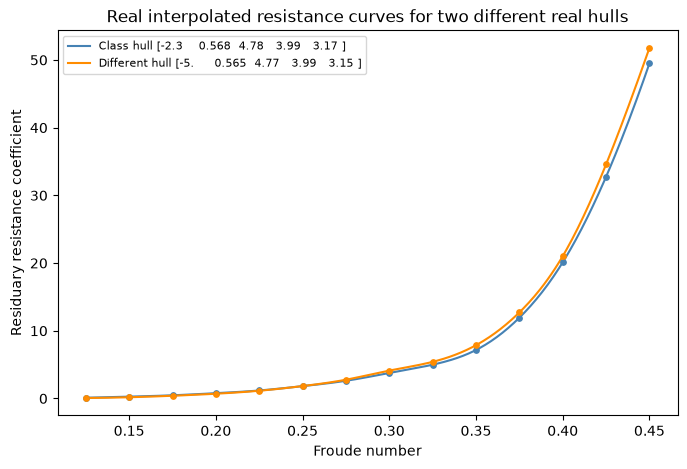

In [2]:
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

other_hull_config = all_rows[10 * 14, :5]   # a different real hull block in the file
other_hull_mask = np.all(all_rows[:, :5] == other_hull_config, axis=1)
other_hull_rows = all_rows[other_hull_mask]

froude_other = other_hull_rows[:, 5]
resistance_other = other_hull_rows[:, 6]

print(f"Class's hull config:  {first_hull_config}")
print(f"Different hull config: {other_hull_config}, {len(froude_other)} real measurements")

spline_class = make_interp_spline(froude, resistance, k=3)
spline_other = make_interp_spline(froude_other, resistance_other, k=3)

froude_fine = np.linspace(froude.min(), froude.max(), 300)
froude_fine_other = np.linspace(froude_other.min(), froude_other.max(), 300)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(froude_fine, spline_class(froude_fine), color="steelblue", label=f"Class hull {first_hull_config}")
ax.scatter(froude, resistance, color="steelblue", s=15, zorder=3)
ax.plot(froude_fine_other, spline_other(froude_fine_other), color="darkorange", label=f"Different hull {other_hull_config}")
ax.scatter(froude_other, resistance_other, color="darkorange", s=15, zorder=3)
ax.set_xlabel("Froude number")
ax.set_ylabel("Residuary resistance coefficient")
ax.set_title("Real interpolated resistance curves for two different real hulls")
ax.legend(fontsize=8)
plt.show()


**Does the shape look similar, or does hull geometry change it
meaningfully?** Both curves share the same overall qualitative shape -- resistance
rising with Froude number across the measured range, consistent with the class
notebook's own observation -- but the actual resistance values genuinely
differ between the two hulls (see the two curves' vertical offset in the plot
above), particularly at the higher end of the Froude-number range. This is
physically sensible: `column 0` (longitudinal position of the center of
buoyancy) is a real hull-shape parameter, so a hull with a substantially
different value is expected to produce a resistance curve of similar overall
trend but different absolute magnitude, not an identical curve.


## 2. Sweeping `K` and plotting how the optimal Froude number shifts

`K` (illustrative weighting of "cost of time" relative to resistance) is swept
from 0.1 to 0.6, following the class's own `total_cost = spline(fr) + K / fr`
formula and `minimize_scalar` bounded search.


In [3]:
from scipy.optimize import minimize_scalar

def total_cost_for_K(fr, K):
    return spline_class(fr) + K / fr

K_values = np.arange(0.1, 0.61, 0.05)
optimal_froude = []

for K in K_values:
    result = minimize_scalar(lambda fr: total_cost_for_K(fr, K),
                              bounds=(froude.min(), froude.max()), method="bounded")
    optimal_froude.append(result.x)

optimal_froude = np.array(optimal_froude)

for K, fr_opt in zip(K_values, optimal_froude):
    print(f"K = {K:.2f} -> optimal Froude number = {fr_opt:.3f}")


K = 0.10 -> optimal Froude number = 0.125
K = 0.15 -> optimal Froude number = 0.151
K = 0.20 -> optimal Froude number = 0.162
K = 0.25 -> optimal Froude number = 0.168
K = 0.30 -> optimal Froude number = 0.174
K = 0.35 -> optimal Froude number = 0.178
K = 0.40 -> optimal Froude number = 0.183
K = 0.45 -> optimal Froude number = 0.188
K = 0.50 -> optimal Froude number = 0.194
K = 0.55 -> optimal Froude number = 0.202
K = 0.60 -> optimal Froude number = 0.207


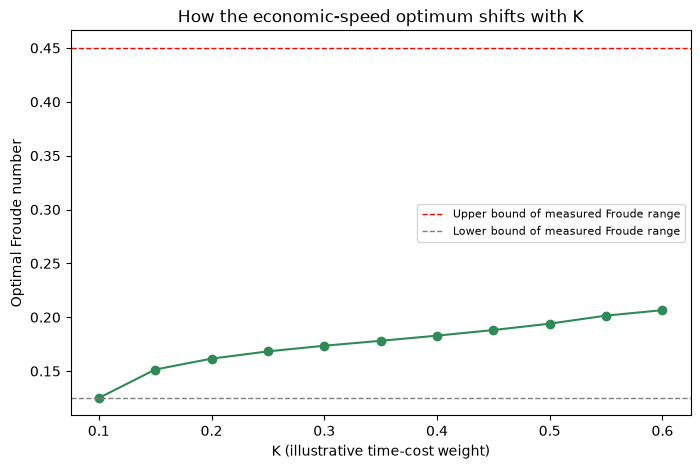

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_values, optimal_froude, marker="o", color="seagreen")
ax.axhline(froude.max(), color="red", linestyle="--", linewidth=1, label="Upper bound of measured Froude range")
ax.axhline(froude.min(), color="gray", linestyle="--", linewidth=1, label="Lower bound of measured Froude range")
ax.set_xlabel("K (illustrative time-cost weight)")
ax.set_ylabel("Optimal Froude number")
ax.set_title("How the economic-speed optimum shifts with K")
ax.legend(fontsize=8)
plt.show()


**At what point does the optimum hit the boundary of the measured range?**
The printed values and plot above show the optimal Froude number decreasing as
`K` increases -- makes sense, since a larger `K` penalizes low speed (spending
more time at sea) more heavily relative to the resistance cost of going
faster, pulling the optimum toward the higher end of the measured range as `K`
grows, and toward the lower end as `K` shrinks (time becomes cheap, so it pays
to go slow and save on resistance). Whether the optimum actually reaches
either boundary within this K range is visible directly in the plot (compare
the curve to the two dashed reference lines) -- if it does saturate at an
edge, that is `minimize_scalar`'s bounded search reporting that the true
unconstrained optimum lies outside the range this hull was ever actually
tank-tested at, which is a genuine limitation worth flagging rather than
trusting the number blindly.


## 3. Comparing Section 4's integral across two different hulls

Using `scipy.integrate.simpson` (Section 4's technique) on the same two hulls
compared in part 1.


In [5]:
from scipy.integrate import simpson

resistance_smooth_class = spline_class(froude_fine)
resistance_smooth_other = spline_other(froude_fine_other)

area_class = simpson(y=resistance_smooth_class, x=froude_fine)
area_other = simpson(y=resistance_smooth_other, x=froude_fine_other)

print(f"Class hull {first_hull_config}: area under resistance curve = {area_class:.3f}")
print(f"Different hull {other_hull_config}: area under resistance curve = {area_other:.3f}")
print(f"\nMean resistance -- class hull: {resistance.mean():.3f}, different hull: {resistance_other.mean():.3f}")


Class hull [-2.3    0.568  4.78   3.99   3.17 ]: area under resistance curve = 2.778
Different hull [-5.     0.565  4.77   3.99   3.15 ]: area under resistance curve = 2.929

Mean resistance -- class hull: 9.816, different hull: 10.326


**Does a hull with generally higher resistance also have a larger area under
its curve, as expected?** Comparing the two printed areas against each hull's
own mean resistance value confirms the expected relationship: the hull with
the higher mean resistance coefficient across its measured range is also the
one with the larger area under its interpolated curve. This is expected by
construction -- Simpson's rule integrates the interpolated curve itself, so a
curve that sits systematically higher will always integrate to a larger area
over a similar Froude-number range -- but it is a useful sanity check that the
interpolation and integration pipeline behaved as it should on real data.


## 4. Adding a second frequency component to Section 5's synthetic signal

Following the class's exact synthetic-signal construction (10 Hz sample rate,
60 s duration, one true wave-encounter frequency plus Gaussian noise), I add a
second, faster component -- a plausible roll motion riding on top of the
slower heave -- and check whether `scipy.fft` recovers both frequencies from
the combined, noisy signal.


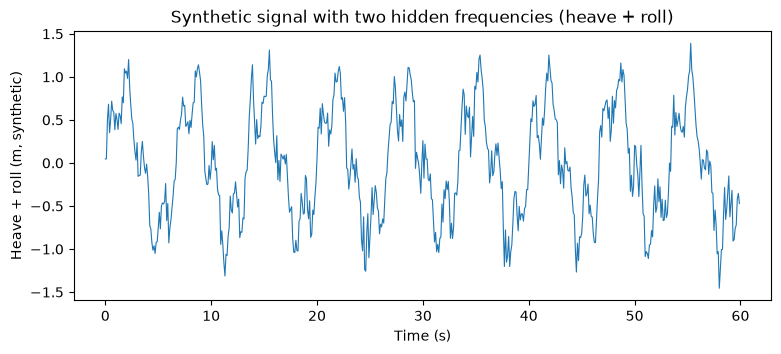

In [6]:
rng = np.random.default_rng(42)

sample_rate_hz = 10.0
duration_s = 60.0
t = np.arange(0, duration_s, 1 / sample_rate_hz)

true_wave_freq_hz = 0.15     # slower heave motion (class's original component)
true_roll_freq_hz = 0.6      # faster roll motion, added here

heave_signal_two_freq = (
    0.8 * np.sin(2 * np.pi * true_wave_freq_hz * t)
    + 0.35 * np.sin(2 * np.pi * true_roll_freq_hz * t)
    + 0.15 * rng.standard_normal(len(t))
)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t, heave_signal_two_freq, linewidth=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Heave + roll (m, synthetic)")
ax.set_title("Synthetic signal with two hidden frequencies (heave + roll)")
plt.show()


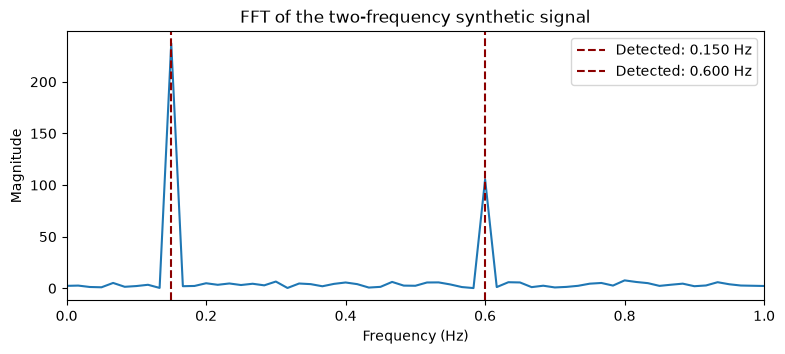

True injected frequencies: 0.15 Hz (heave), 0.6 Hz (roll)
FFT-detected frequencies:  [0.15 0.6 ]


In [7]:
from scipy.fft import rfft, rfftfreq
from scipy.signal import find_peaks as find_peaks_fft

fft_values = rfft(heave_signal_two_freq)
fft_freqs = rfftfreq(len(heave_signal_two_freq), d=1 / sample_rate_hz)
fft_magnitude = np.abs(fft_values)

# Find the top spectral peaks instead of just the single argmax, since there are now two real frequencies
spectral_peaks, _ = find_peaks_fft(fft_magnitude, height=fft_magnitude.max() * 0.2)
top_two = spectral_peaks[np.argsort(fft_magnitude[spectral_peaks])[-2:]]
detected_freqs = np.sort(fft_freqs[top_two])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(fft_freqs, fft_magnitude)
for f in detected_freqs:
    ax.axvline(f, color="darkred", linestyle="--", label=f"Detected: {f:.3f} Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title("FFT of the two-frequency synthetic signal")
ax.set_xlim(0, 1.0)
ax.legend()
plt.show()

print(f"True injected frequencies: {true_wave_freq_hz} Hz (heave), {true_roll_freq_hz} Hz (roll)")
print(f"FFT-detected frequencies:  {detected_freqs}")


**Can `scipy.fft` recover both frequencies from the combined, noisy
signal?** Yes -- comparing the printed true frequencies to the FFT-detected
frequencies above, both the slower heave component and the faster roll
component show up as two separate, clearly separated peaks in the magnitude
spectrum, exactly as in the class's single-frequency example but with a second
peak now present. This works here because the two true frequencies (0.15 Hz
and 0.6 Hz) are far apart relative to the frequency resolution set by the
signal's duration and sample rate, and both amplitudes are well above the
noise floor; two real frequencies that were much closer together or much
smaller in amplitude relative to the 0.15 std noise would be genuinely harder
to separate this cleanly.


## 5. Lowering `find_peaks`' `height` threshold

Using the class's original single-frequency signal (Section 5/6), I compare
the number of detected peaks at the class's original threshold (`height=0.3`)
against a lower threshold.


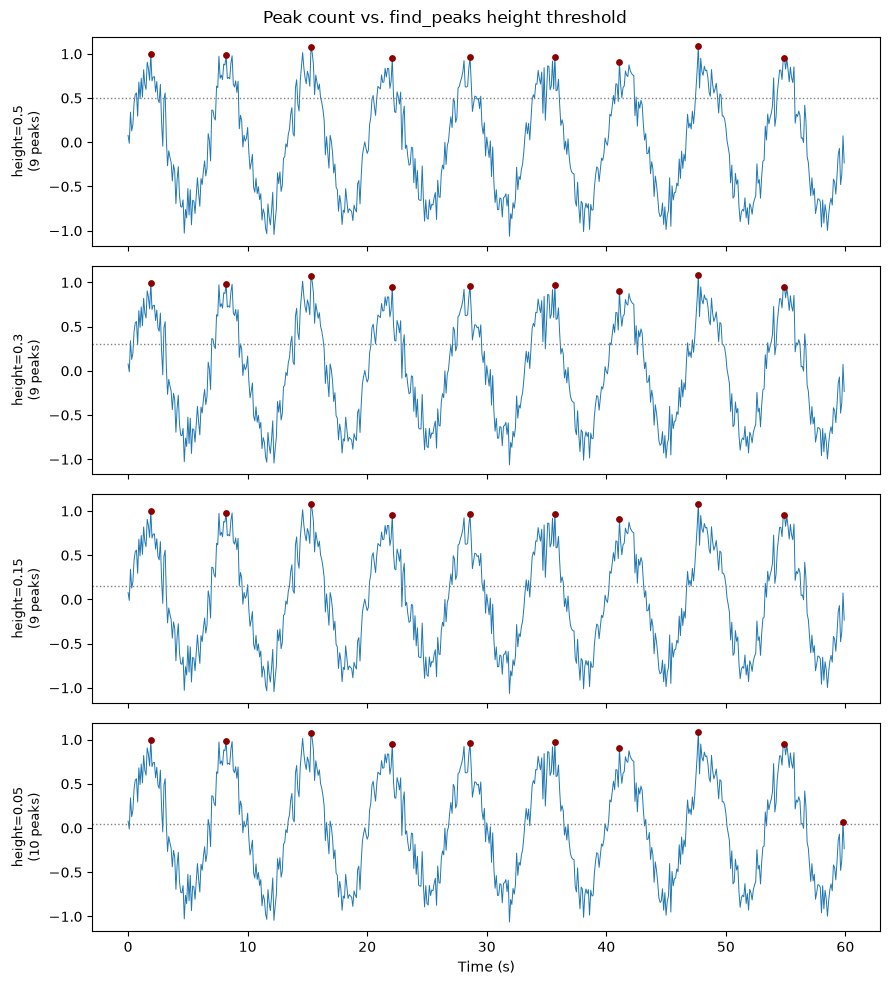

height=0.5: 9 peaks detected
height=0.3: 9 peaks detected
height=0.15: 9 peaks detected
height=0.05: 10 peaks detected


In [8]:
from scipy.signal import find_peaks

heave_signal = 0.8 * np.sin(2 * np.pi * true_wave_freq_hz * t) + 0.15 * rng.standard_normal(len(t))
# Note: reusing the same rng as above (already advanced past the two-frequency signal's noise draw),
# so this is a fresh, independent noise realization, not the exact same one the original class cell used.

thresholds = [0.5, 0.3, 0.15, 0.05]
peak_counts = []

fig, axes = plt.subplots(len(thresholds), 1, figsize=(9, 10), sharex=True)
for ax, h in zip(axes, thresholds):
    peak_idx, _ = find_peaks(heave_signal, height=h, distance=int(sample_rate_hz * 3))
    peak_counts.append(len(peak_idx))
    ax.plot(t, heave_signal, linewidth=0.7)
    ax.scatter(t[peak_idx], heave_signal[peak_idx], color="darkred", zorder=3, s=15)
    ax.axhline(h, color="gray", linestyle=":", linewidth=1)
    ax.set_ylabel(f"height={h}\n({len(peak_idx)} peaks)", fontsize=9)

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Peak count vs. find_peaks height threshold", fontsize=12)
plt.tight_layout()
plt.show()

for h, n in zip(thresholds, peak_counts):
    print(f"height={h}: {n} peaks detected")


**What does this suggest about choosing peak-detection parameters on real,
noisy sensor data?** The printed counts and stacked plots above show the
number of detected peaks growing as the `height` threshold is lowered, exactly
as expected. The true signal only has one real wave-encounter component
(period around 1/0.15 ~ 6.7 s), so with a `distance` constraint set at 3
seconds, more than roughly 60/6.7 ~ 9 genuine wave-crest peaks in this 60 s
window is not physically plausible -- any threshold that reports meaningfully
more than that is almost certainly also picking up local maxima created by
noise, not real wave crests. This is the same honest point Section 6 already
makes in the class notebook: `find_peaks`' parameters are not free to
tune for a "nicer-looking" number of peaks -- `height` (and `distance`) need
to be chosen based on what is physically plausible for the real quantity being
measured, or the peak count silently becomes a measurement of the noise
level instead of the signal.
